In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid") # Set a consistent theme for all plots
plt.rcParams['figure.dpi'] = 100 # Set a higher resolution for plots


In [4]:
df = pd.read_csv('../data/hotel_bookings_clean.csv')

df.shape

(113380, 34)

In [7]:
segment = df.groupby('market_segment')['adr'].mean().round(2).sort_values(ascending=False)
print(segment)

market_segment
Online TA        111.19
Direct           106.91
Aviation         102.74
Offline TA/TO     87.66
Groups            79.61
Corporate         70.17
Complementary     34.04
Undefined         15.00
Name: adr, dtype: float64


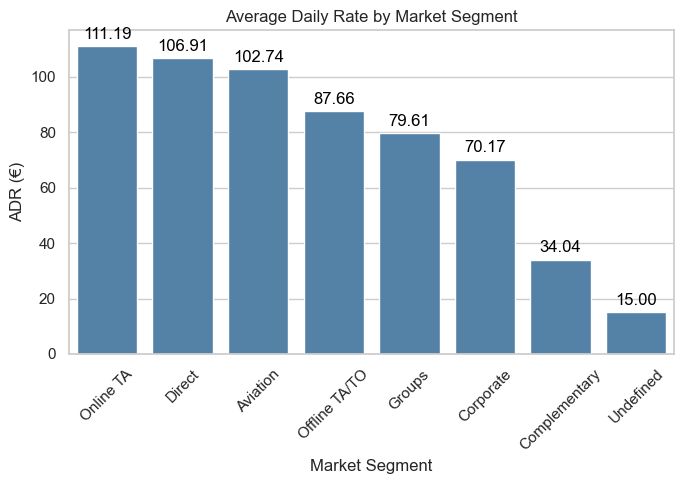

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=segment.index,
            y=segment.values,
            color='steelblue',
            ax=ax)
ax.bar_label(ax.containers[0], fmt='%.2f', padding=3, color='black')
plt.title('Average Daily Rate by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('ADR (€)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../exports/adr_by_market_segment.png', bbox_inches='tight')
plt.show()

In [20]:
decoup = pd.cut(df['lead_time'], bins=[0, 7, 30, 90, 180, np.inf], labels=['0-7', '8-30', '31-90', '91-180', '180+'])

df['lead_time_group'] = decoup

df.groupby('lead_time_group')['adr'].mean().round(2)

C:\Users\user\AppData\Local\Temp\ipykernel_4952\2842118579.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('lead_time_group')['adr'].mean().round(2)


lead_time_group
0-7        92.38
8-30      102.45
31-90     101.23
91-180    104.48
180+       91.56
Name: adr, dtype: float64

C:\Users\user\AppData\Local\Temp\ipykernel_4952\2759290816.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lead_time_adr = df.groupby('lead_time_group')['adr'].mean().round(2)


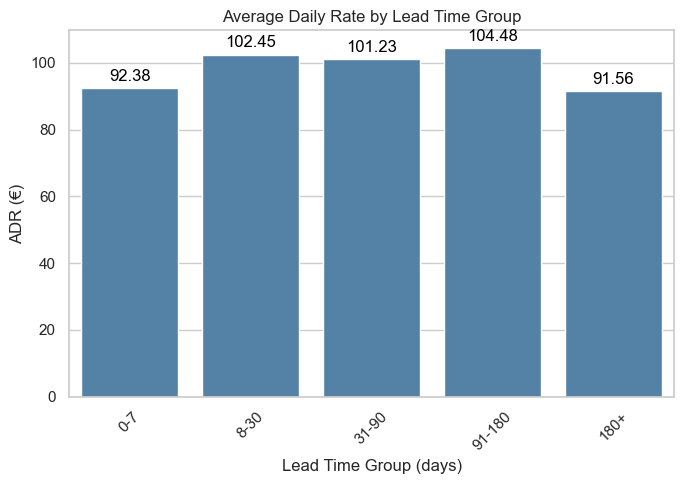

In [25]:
fig , ax = plt.subplots(figsize=(7, 5))
lead_time_adr = df.groupby('lead_time_group')['adr'].mean().round(2)
sns.barplot(x=lead_time_adr.index, 
            y=lead_time_adr.values,
            color='steelblue',
            ax= ax)
ax.bar_label(ax.containers[0], fmt='%.2f', padding=3, color='black'),
plt.title('Average Daily Rate by Lead Time Group')
plt.xlabel('Lead Time Group (days)')
plt.ylabel('ADR (€)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../exports/adr_by_lead_time_group.png', bbox_inches='tight')
plt.show()

